In [1]:
import pathlib

import h5py
import torch
from matplotlib import pyplot as plt

from artist.core.heliostat_ray_tracer import HeliostatRayTracer
from artist.core.loss_functions import KLDivergenceLoss
from artist.core.motor_position_optimizer import MotorPositionsOptimizer
from artist.scenario.scenario import Scenario
from artist.util import config_dictionary, index_mapping, set_logger_config, utils
from artist.util.environment_setup import get_device, setup_distributed_environment

torch.manual_seed(7)
torch.cuda.manual_seed(7)

#############################################################################################################
# Define helper functions for the plots.
# Skip to line 149 for the tutorial code.
#############################################################################################################


def create_flux_plot_before_optimization(bitmap_resolution, device, scenario, incident_ray_direction, target_area_index) -> None:
    """Create data to plot the heliostat fluxes."""
    total_flux = torch.zeros(
        (
            bitmap_resolution[index_mapping.unbatched_bitmap_e],
            bitmap_resolution[index_mapping.unbatched_bitmap_u],
        ),
        device=device,
    )

    for heliostat_group_index, heliostat_group in enumerate(
        scenario.heliostat_field.heliostat_groups
    ):
        (active_heliostats_mask, target_area_mask, incident_ray_directions) = (
            scenario.index_mapping(
                heliostat_group=heliostat_group,
                single_incident_ray_direction=incident_ray_direction,
                single_target_area_index=target_area_index,
                device=device,
            )
        )

        # Activate heliostats.
        heliostat_group.activate_heliostats(
            active_heliostats_mask=active_heliostats_mask,
            device=device,
        )

        # Align heliostats.
        heliostat_group.align_surfaces_with_incident_ray_directions(
            aim_points=scenario.target_areas.centers[target_area_mask],
            incident_ray_directions=incident_ray_directions,
            active_heliostats_mask=active_heliostats_mask,
            device=device,
        )

        # Create a ray tracer.
        ray_tracer = HeliostatRayTracer(
            scenario=scenario,
            heliostat_group=heliostat_group,
            batch_size=heliostat_group.number_of_active_heliostats,
            bitmap_resolution=torch.tensor([256, 256], device=device),
        )

        # Perform heliostat-based ray tracing.
        bitmaps_per_heliostat = ray_tracer.trace_rays(
            incident_ray_directions=incident_ray_directions,
            active_heliostats_mask=active_heliostats_mask,
            target_area_mask=target_area_mask,
            device=device,
        )

        flux_distribution_on_target = ray_tracer.get_bitmaps_per_target(
            bitmaps_per_heliostat=bitmaps_per_heliostat,
            target_area_mask=target_area_mask,
            device=device,
        )[target_area_index]

        total_flux += flux_distribution_on_target

    # Create the plot.
    plt.imshow(flux_distribution_on_target.cpu().detach(), cmap="gray")
    plt.axis("off")
    plt.title("Flux before aimpoint optimization")
    plt.savefig("flux_before_aimpoint_optimization.png")


def create_flux_plot_after_optimization(bitmap_resolution, device, scenario, incident_ray_direction, target_area_index) -> None:
    """Create data to plot the heliostat fluxes."""
    total_flux = torch.zeros(
        (
            bitmap_resolution[index_mapping.unbatched_bitmap_e],
            bitmap_resolution[index_mapping.unbatched_bitmap_u],
        ),
        device=device,
    )

    for heliostat_group_index, heliostat_group in enumerate(
        scenario.heliostat_field.heliostat_groups
    ):
        (active_heliostats_mask, target_area_mask, incident_ray_directions) = (
            scenario.index_mapping(
                heliostat_group=heliostat_group,
                single_incident_ray_direction=incident_ray_direction,
                single_target_area_index=target_area_index,
                device=device,
            )
        )

        # Activate heliostats.
        heliostat_group.activate_heliostats(
            active_heliostats_mask=active_heliostats_mask,
            device=device,
        )

        # Align heliostats.
        heliostat_group.align_surfaces_with_motor_positions(
            motor_positions=heliostat_group.kinematic.active_motor_positions,
            active_heliostats_mask=active_heliostats_mask,
            device=device,
        )

        # Create a ray tracer.
        ray_tracer = HeliostatRayTracer(
            scenario=scenario,
            heliostat_group=heliostat_group,
            batch_size=heliostat_group.number_of_active_heliostats,
            bitmap_resolution=torch.tensor([256, 256], device=device),
        )

        # Perform heliostat-based ray tracing.
        bitmaps_per_heliostat = ray_tracer.trace_rays(
            incident_ray_directions=incident_ray_directions,
            active_heliostats_mask=active_heliostats_mask,
            target_area_mask=target_area_mask,
            device=device,
        )

        flux_distribution_on_target = ray_tracer.get_bitmaps_per_target(
            bitmaps_per_heliostat=bitmaps_per_heliostat,
            target_area_mask=target_area_mask,
            device=device,
        )[target_area_index]

        total_flux += flux_distribution_on_target

    # Create the plot.
    plt.imshow(flux_distribution_on_target.cpu().detach(), cmap="gray")
    plt.axis("off")
    plt.title("Flux after aimpoint optimization")
    plt.savefig("flux_after_aimpoint_optimization.png")


#############################################################################################################
# Tutorial
#############################################################################################################


def optimize_motor_scenario(path_to_scenario):
    # Set up logger.
    set_logger_config()

    # Set the device.
    device = get_device()

    scenario_path = pathlib.Path(path_to_scenario)
    number_of_heliostat_groups = Scenario.get_number_of_heliostat_groups_from_hdf5(
        scenario_path=scenario_path
    )

    with setup_distributed_environment(
        number_of_heliostat_groups=number_of_heliostat_groups,
        device=device,
    ) as ddp_setup:
        device = ddp_setup[config_dictionary.device]

        # Load the scenario.
        with h5py.File(scenario_path, "r") as scenario_file:
            scenario = Scenario.load_scenario_from_hdf5(
                scenario_file=scenario_file,
                device=device,
            )

        scenario.set_number_of_rays(number_of_rays=4)

        # Set loss function and define the ground truth.
        # For an optimization using a focal spot as ground truth use this loss definition:
        # ground_truth = torch.tensor(
        #     [1.1493, -0.5030, 57.0474, 1.0000], device=device
        # )
        # loss_definition = FocalSpotLoss(scenario=scenario)

        # For an optimization using a distribution as target use this loss function definition:
        e_trapezoid = utils.trapezoid_distribution(
            total_width=256, slope_width=30, plateau_width=180, device=device
        )
        u_trapezoid = utils.trapezoid_distribution(
            total_width=256, slope_width=30, plateau_width=180, device=device
        )
        ground_truth = u_trapezoid.unsqueeze(
            index_mapping.unbatched_bitmap_u
        ) * e_trapezoid.unsqueeze(index_mapping.unbatched_bitmap_e)
        loss_definition = KLDivergenceLoss()

        # Configure the learning rate scheduler. The example scheduler parameter dict includes
        # example parameters for all three possible schedulers.
        scheduler = (
            config_dictionary.reduce_on_plateau
        )  # Choose from: exponential, cyclic or reduce_on_plateau
        scheduler_parameters = {
            config_dictionary.gamma: 0.9,
            config_dictionary.min: 1e-6,
            config_dictionary.max: 1e-3,
            config_dictionary.step_size_up: 500,
            config_dictionary.reduce_factor: 0.3,
            config_dictionary.patience: 100,
            config_dictionary.threshold: 1e-3,
            config_dictionary.cooldown: 10,
        }

        # Set optimizer parameters.
        optimization_configuration = {
            config_dictionary.initial_learning_rate: 1e-3,
            config_dictionary.tolerance: 0.0005,
            config_dictionary.max_epoch: 30,
            config_dictionary.log_step: 3,
            config_dictionary.early_stopping_delta: 1e-4,
            config_dictionary.early_stopping_patience: 100,
            config_dictionary.scheduler: scheduler,
            config_dictionary.scheduler_parameters: scheduler_parameters,
        }

        incident_ray_direction = torch.tensor([0.0, 1.0, 0.0, 0.0], device=device)
        target_area_index = 1
        bitmap_resolution = torch.tensor([256, 256], device=device)

        create_flux_plot_before_optimization(bitmap_resolution, device, scenario, incident_ray_direction, target_area_index)

        # Create the motor positions optimizer.
        motor_positions_optimizer = MotorPositionsOptimizer(
            ddp_setup=ddp_setup,
            scenario=scenario,
            optimization_configuration=optimization_configuration,
            incident_ray_direction=incident_ray_direction,
            target_area_index=target_area_index,
            ground_truth=ground_truth,
            bitmap_resolution=bitmap_resolution,
            device=device,
        )

        # Optimize the motor positions.
        final_loss_per_heliostat = motor_positions_optimizer.optimize(
            loss_definition=loss_definition, device=device
        )

    # Inspect the synchronized loss per heliostat. Heliostats that have not been optimized have an infinite loss.
    print(f"rank {ddp_setup['rank']}, final loss {final_loss_per_heliostat}")

    create_flux_plot_after_optimization(bitmap_resolution, device, scenario, incident_ray_direction, target_area_index)

In [2]:
scenario_paths = [
    # "tutorials/data/scenarios/single_heliostat_scenario.h5"
    "scenarios/one_heliostat_scenarios/AA31_one_heliostat_scenario.h5",
    # "scenarios/one_heliostat_scenarios/test_scenario.h5"
]

[2025-12-26 02:06:40,241][artist.util.environment_setup][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2025-12-26 02:06:40,242][artist.util.environment_setup][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
[2025-12-26 02:06:40,243][artist.util.environment_setup][INFO] - Distributed Mode disabled. Running in single-device mode.
[2025-12-26 02:06:40,244][artist.scenario.scenario][INFO] - Loading an ARTIST scenario HDF5 file. This scenario file is version 1.0.
[2025-12-26 02:06:40,244][artist.field.tower_target_areas][INFO] - Loading the tower target areas from an HDF5 file.
[2025-12-26 02:06:40,245][artist.field.tower_target_areas][WARNING] - No curvature in the east direction set for the multi_focus_tower!
[2025-12-26 02:06:40,245][artist.field.tower_target_areas][WARNING] - No curvature in the up direction set for the multi_focus_tower!
[2025-12-26 02:06:40,246][artist.field.tower_target_areas][WA

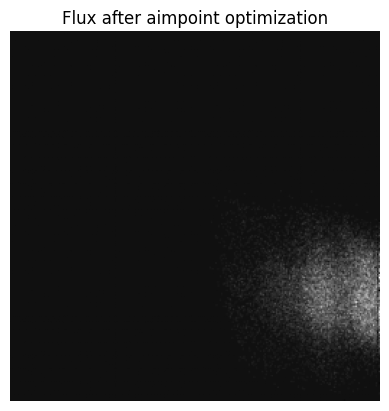

In [3]:
optimize_motor_scenario(scenario_paths[0])